In [2]:
import pandas as pd 

In [3]:
df=pd.read_csv("emp_class.csv")

In [4]:
df.info()
df.head()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

0

In [5]:
# this means no duplicates in data 

In [6]:
print(df.head())
print(df.tail())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [7]:
(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df["Attrition"].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [9]:
# ("checking relations between variables")
pd.crosstab(df['OverTime'], df["Attrition"], normalize='index')*100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [10]:
# shows strong corelation effect

In [11]:
pd.crosstab(df["JobSatisfaction"],df["Attrition"],normalize="index")*100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


In [12]:
pd.crosstab(df["Gender"],df["Attrition"],normalize="index")

Attrition,No,Yes
Gender,,
Female,0.852041,0.147959
Male,0.829932,0.170068


In [13]:
pd.crosstab(df["WorkLifeBalance"],df["Attrition"],normalize="index")*100

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


In [14]:
# dropping useless columns

In [15]:
df = df.drop(['EmployeeCount',
              'EmployeeNumber',
              'Over18',
              'StandardHours'], axis=1)

In [16]:
# encoding attrition to 0 or 1

In [17]:
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [18]:
# Splitting attrition from data
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [19]:
# Categoricall data encoding 
X = pd.get_dummies(X, drop_first=True)

In [20]:
X

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,True,False,False,False,False,False,False,True,False,False
1466,39,613,6,1,4,42,2,3,1,9991,...,False,False,False,False,False,False,False,True,False,False
1467,27,155,4,3,2,87,4,2,2,6142,...,False,False,True,False,False,False,False,True,False,True
1468,49,1023,2,3,4,63,2,2,2,5390,...,False,False,False,False,False,True,False,True,False,False


In [21]:
# train test splitting
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
# scaling data 

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [25]:
# Train logistic regression

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[192  55]
 [ 18  29]]
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [27]:
coef_df = pd.Series(model.coef_[0], index=X.columns)
coef_df = coef_df.sort_values()

print("Top Positive Predictors (Increase Attrition):")
print(coef_df.tail(10))

print("\nTop Negative Predictors (Decrease Attrition):")
print(coef_df.head(10))

Top Positive Predictors (Increase Attrition):
MaritalStatus_Single                0.455366
NumCompaniesWorked                  0.464327
Department_Sales                    0.470587
YearsSinceLastPromotion             0.499063
BusinessTravel_Travel_Rarely        0.512780
JobRole_Sales Representative        0.531090
JobLevel                            0.650173
BusinessTravel_Travel_Frequently    0.722538
OverTime_Yes                        0.771095
JobRole_Laboratory Technician       0.810172
dtype: float64

Top Negative Predictors (Decrease Attrition):
TotalWorkingYears              -0.660270
EducationField_Life Sciences   -0.512319
YearsWithCurrManager           -0.461322
EducationField_Medical         -0.452134
EnvironmentSatisfaction        -0.434370
JobSatisfaction                -0.393219
EducationField_Other           -0.389932
JobRole_Research Director      -0.388326
JobInvolvement                 -0.285370
Age                            -0.266981
dtype: float64


In [28]:
# classification tree

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Results:")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Results:
[[207  40]
 [ 29  18]]
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       247
           1       0.31      0.38      0.34        47

    accuracy                           0.77       294
   macro avg       0.59      0.61      0.60       294
weighted avg       0.79      0.77      0.77       294



In [30]:
# roc au score

In [31]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.7982599707123783


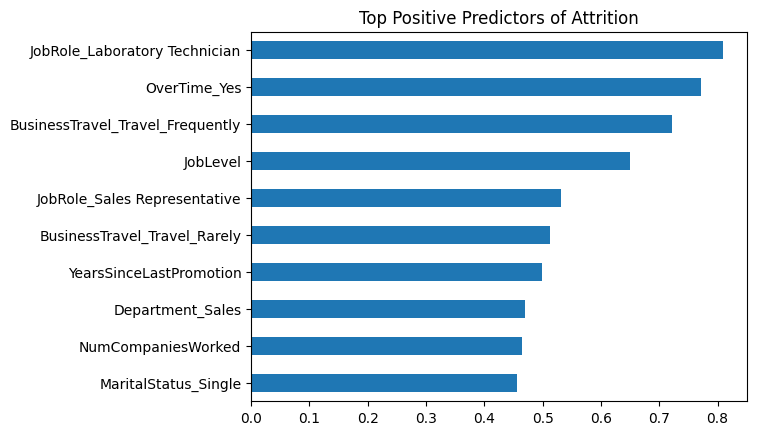

In [32]:
import matplotlib.pyplot as plt

coef_df.sort_values().tail(10).plot(kind='barh')
plt.title("Top Positive Predictors of Attrition")
plt.show()

In [33]:
# hypothesis1: employees who work overtime are more likely to win 
# hypothesis 2:employees with low satistfaction rate show higher attritition rates


In [34]:
# composition and attrition
df.groupby('Attrition')['MonthlyIncome'].mean()

Attrition
0    6832.739659
1    4787.092827
Name: MonthlyIncome, dtype: float64

In [35]:
# lower salary group indicating higher attrition

In [ ]:
# final EDA summary
# Key drivers identified during EDA include overtime, job role, and job satisfaction.
# These behavioral and organizational factors appear to significantly influence attrition risk and will inform the predictive modeling phase.